# Regularized Regression for Return Prediction

**Chapter 11 | Section 11.2**

**Docker image**: `ml4t`

This notebook compares OLS, Ridge (L2), LASSO (L1), and Elastic Net regression
for predicting 21-day forward returns on the ETF universe (99 series, after one
all-null series is dropped). All models share the same
8-fold walk-forward CV from `setup.yaml`, ensuring apples-to-apples comparison.

**Learning objectives**

- Understand the bias-variance tradeoff in regularized regression
- Compare Ridge, LASSO, and Elastic Net on real financial features
- Analyze regularization paths and LASSO feature selection
- Evaluate predictive performance via Information Coefficient (IC)

**Book reference**

Section 11.2 ("Regularized Regression"). The next notebook,
`03_logistic_classification`, applies the same regularization toolkit to the
direction-prediction task; `04_nested_cv_hpo` extends the alpha sweep into
nested cross-validation.

**Prerequisites**

- Working knowledge of OLS and the bias-variance tradeoff.
- Conceptual exposure to L1, L2, and Elastic-Net penalties.
- ETF case-study features at `case_studies/etfs/features/financial.parquet`
  (Ch8) and labels at `case_studies/etfs/labels/fwd_ret_21d.parquet` (Ch7).

**Downstream**: Ch12 (gradient boosting), Ch16-17 (backtesting + portfolio).

## Setup

In [1]:
"""Regularized Regression for Return Prediction — compare Ridge, LASSO, and Elastic Net via walk-forward CV."""

import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.colors import ListedColormap
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from scipy.stats import spearmanr
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
    SGDRegressor,
    lasso_path,
)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir, get_chapter_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
MAX_SYMBOLS = 0
RETRAIN = False

In [3]:
RANDOM_SEED = SEED
set_global_seeds(SEED)

## Load Features and Labels

We load pre-computed ETF features from Ch8 and 21-day forward return labels
from Ch7. No synthetic fallback — if files are missing, run upstream notebooks.

In [4]:
CASE_DIR = get_case_study_dir("etfs")
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"
LABELS_PATH = CASE_DIR / "labels" / "fwd_ret_21d.parquet"

assert FEATURES_PATH.exists(), (
    f"Features not found: {FEATURES_PATH}\nRun the Ch8 ETF features notebook first."
)
assert LABELS_PATH.exists(), (
    f"Labels not found: {LABELS_PATH}\nRun the Ch7 ETF labels notebook first."
)

features_df = pl.read_parquet(FEATURES_PATH).with_columns(pl.col("timestamp").cast(pl.Date))
labels_df = pl.read_parquet(LABELS_PATH).with_columns(pl.col("timestamp").cast(pl.Date))

In [5]:
TARGET_COL = "fwd_ret_21d"
ASSET_COL = "symbol"

df = features_df.join(labels_df, on=["timestamp", ASSET_COL], how="inner")

META_COLS = {"timestamp", ASSET_COL, TARGET_COL}
FEATURE_COLS = sorted(c for c in df.columns if c not in META_COLS)

# Drop features that are entirely null (can happen with reduced test universes)
all_null = [c for c in FEATURE_COLS if df[c].null_count() == df.height]
if all_null:
    print(f"Dropping {len(all_null)} all-null features: {all_null}")
    df = df.drop(all_null)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_null]

# Replace inf/NaN with null, then drop all nulls
df = df.with_columns(
    [
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(None)
        .otherwise(pl.col(c))
        .alias(c)
        for c in FEATURE_COLS
    ]
)
df = df.drop_nulls(subset=FEATURE_COLS + [TARGET_COL]).sort(["timestamp", ASSET_COL])

if MAX_SYMBOLS > 0:
    assets = df[ASSET_COL].unique().sort().head(MAX_SYMBOLS).to_list()
    df = df.filter(pl.col(ASSET_COL).is_in(assets))

print(f"Shape: {df.height:,} rows x {len(FEATURE_COLS)} features")
print(f"Assets: {df[ASSET_COL].n_unique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Shape: 393,985 rows x 57 features
Assets: 99
Date range: 2007-01-04 to 2025-12-01


## Walk-Forward Cross-Validation Setup

We load the canonical walk-forward splits from `setup.yaml` via
`generate_cv_splits`: rolling train/validation windows with purge gap.
This ensures consistency across all Ch11 notebooks and case studies.

In [6]:
splits = generate_cv_splits(df, case_study_id="etfs", label_buffer="21D", date_col="timestamp")

features_array = df.select(FEATURE_COLS).to_numpy()
target_array = df[TARGET_COL].to_numpy()
dates_np = df["timestamp"].to_numpy()
symbols_np = df[ASSET_COL].to_numpy()

cv_splits = []
for s in splits:
    tr_start, tr_end = np.datetime64(s["train_start"]), np.datetime64(s["train_end"])
    te_start, te_end = np.datetime64(s["val_start"]), np.datetime64(s["val_end"])
    train_idx = np.where((dates_np >= tr_start) & (dates_np <= tr_end))[0]
    test_idx = np.where((dates_np >= te_start) & (dates_np <= te_end))[0]
    if len(train_idx) > 0 and len(test_idx) > 0:
        cv_splits.append((train_idx, test_idx))

train_sizes = [len(tr) for tr, _ in cv_splits]
test_sizes = [len(te) for _, te in cv_splits]
if cv_splits:
    print(
        f"{len(cv_splits)} walk-forward folds — train size "
        f"{min(train_sizes):,}–{max(train_sizes):,}, test size "
        f"{min(test_sizes):,}–{max(test_sizes):,}"
    )
else:
    print("0 walk-forward folds — every candidate split failed the train/test size gate")

8 walk-forward folds — train size 157,172–226,959, test size 22,170–24,192


## Helper Functions

In [7]:
def cross_sectional_ic_mean(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dates: np.ndarray,
    symbols: np.ndarray,
) -> float:
    """Mean cross-sectional Spearman IC across dates in the test fold."""
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    return float(ic_per_date.drop_nulls("ic")["ic"].mean())


def evaluate_predictions(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dates: np.ndarray,
    symbols: np.ndarray,
) -> dict:
    """Compute mean cross-sectional IC, RMSE, and R-squared on a test fold."""
    ic = cross_sectional_ic_mean(y_true, y_pred, dates, symbols)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"ic": ic, "rmse": rmse, "r2": r2}

### Winsorization

Clipping features at the 1st and 99th percentiles (computed on training data)
limits the influence of extreme observations on standardization. Without
winsorization, a single outlier can inflate $\sigma_j$ and compress all other
observations toward zero. The percentile bounds are fitted on training data
only to prevent look-ahead bias.

In [8]:
def winsorize_train_test(
    X_train: np.ndarray, X_test: np.ndarray, lower: float = 1.0, upper: float = 99.0
) -> tuple[np.ndarray, np.ndarray]:
    """Clip features at training-set percentiles to limit outlier influence."""
    lo = np.percentile(X_train, lower, axis=0)
    hi = np.percentile(X_train, upper, axis=0)
    return np.clip(X_train, lo, hi), np.clip(X_test, lo, hi)

### Walk-Forward Cross-Validation
Run walk-forward CV with per-fold winsorization and standardization.

In [9]:
def cross_validate(
    model_class, model_params: dict
) -> tuple[list[dict], list[np.ndarray], list[dict]]:
    """Run walk-forward CV on pre-computed splits.

    Preprocessing per fold: winsorize (1st/99th on train) → standardize.
    Returns per-fold metrics, coefficient arrays, and (model, scaler) pairs.
    """
    results, coefficients, fold_models = [], [], []

    for i, (train_idx, test_idx) in enumerate(cv_splits):
        X_tr, X_te = features_array[train_idx], features_array[test_idx]
        y_tr, y_te = target_array[train_idx], target_array[test_idx]

        # Winsorize before standardizing (percentiles fitted on training data)
        X_tr, X_te = winsorize_train_test(X_tr, X_te)

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        model = model_class(**model_params)
        model.fit(X_tr_s, y_tr)

        y_pred = model.predict(X_te_s)
        metrics = evaluate_predictions(y_te, y_pred, dates_np[test_idx], symbols_np[test_idx])
        metrics["fold"] = i + 1
        metrics["train_size"] = len(X_tr)
        metrics["test_size"] = len(X_te)
        results.append(metrics)

        if hasattr(model, "coef_"):
            coefficients.append(model.coef_.ravel().copy())
        fold_models.append({"model": model, "scaler": scaler})

    return results, coefficients, fold_models

## Model Cache

Training results (including fitted models and scalers) are cached to disk.
Set `RETRAIN = True` to force retraining.

In [10]:
MODELS_DIR = get_chapter_dir(11) / "models" / "02_regularization_paths"
RESULTS_PATH = MODELS_DIR / "cv_results.joblib"
NEED_TRAINING = RETRAIN or not RESULTS_PATH.exists()

if not NEED_TRAINING:
    _cached = joblib.load(RESULTS_PATH)
    ols_df = _cached["ols_df"]
    ols_coeffs = _cached["ols_coeffs"]
    ols_models = _cached["ols_models"]
    ridge_all = _cached["ridge_all"]
    ridge_summary = _cached["ridge_summary"]
    best_ridge_alpha = _cached["best_ridge_alpha"]
    RIDGE_ALPHAS = _cached["RIDGE_ALPHAS"]
    lasso_all = _cached["lasso_all"]
    lasso_summary = _cached["lasso_summary"]
    best_lasso_alpha = _cached["best_lasso_alpha"]
    alpha_max = _cached["alpha_max"]
    LASSO_ALPHAS = _cached["LASSO_ALPHAS"]
    en_all = _cached["en_all"]
    en_summary = _cached["en_summary"]
    best_en_key = _cached.get("best_en_key", en_summary.row(0, named=True)["params"])
    path_alphas = _cached["path_alphas"]
    path_coefs = _cached["path_coefs"]
    loss_comparison = _cached.get("loss_comparison")
    del _cached
    print(
        f"  Ridge: {len(ridge_all)} alphas | LASSO: {len(lasso_all)} alphas | EN: {len(en_all)} ratios"
    )
else:
    print("Training models (RETRAIN=True or no cache found)...")

  Ridge: 23 alphas | LASSO: 10 alphas | EN: 3 ratios


## OLS Baseline

Ordinary Least Squares provides an unregularized reference point.
With 57 features on noisy financial data, we expect overfitting.

In [11]:
if NEED_TRAINING:
    res, coeffs, models = cross_validate(LinearRegression, {})
    ols_df = pl.DataFrame(res)
    ols_coeffs = coeffs
    ols_models = models

In [12]:
print(f"OLS - Mean IC: {ols_df['ic'].mean():.4f} (std: {ols_df['ic'].std():.4f})")
ols_df.select("fold", "ic", "rmse", "r2", "train_size", "test_size")

OLS - Mean IC: 0.0284 (std: 0.0526)


fold,ic,rmse,r2,train_size,test_size
i64,f64,f64,f64,i64,i64
1,-0.007099,0.054599,-0.130122,226959,24190
2,0.077497,0.075132,-0.029538,222604,23939
3,0.133413,0.046895,0.029617,217511,23938
4,0.040759,0.098881,0.038727,210417,23939
5,-0.009985,0.046723,-0.212635,203067,24192
6,-0.013426,0.047866,-0.073753,192230,24186
7,0.000556,0.039493,-0.387212,179363,23657
8,0.005761,0.05538,-0.180324,157172,22170


## Ridge Regression (L2)

Ridge shrinks all coefficients towards zero without setting any exactly to zero.
We sweep 23 log-spaced $\alpha$ values from $10^{-2}$ to $10^{9}$, covering the
full transition from under-regularized (indistinguishable from OLS) through the
optimal range to over-regularized (coefficients crushed to near zero).

In [13]:
if NEED_TRAINING:
    RIDGE_ALPHAS = np.logspace(-2, 9, 23)
    ridge_all = {}

    for alpha in RIDGE_ALPHAS:
        res, coeffs, models = cross_validate(Ridge, {"alpha": alpha, "random_state": RANDOM_SEED})
        ridge_all[alpha] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "models": models,
        }

    ridge_summary = pl.DataFrame(
        [
            {"alpha": a, "mean_ic": d["results"]["ic"].mean(), "std_ic": d["results"]["ic"].std()}
            for a, d in ridge_all.items()
        ]
    ).sort("mean_ic", descending=True)

    best_ridge_alpha = ridge_summary.row(0, named=True)["alpha"]

In [14]:
print(
    f"Best Ridge alpha: {best_ridge_alpha:.2f}  IC: {ridge_summary.filter(pl.col('alpha') == best_ridge_alpha)['mean_ic'].item():.4f}"
)
ridge_summary

Best Ridge alpha: 31622.78  IC: 0.0473


alpha,mean_ic,std_ic
f64,f64,f64
31622.776602,0.047338,0.058075
100000.0,0.046364,0.048614
316227.766017,0.045983,0.037497
1e6,0.045605,0.035134
10000.0,0.044863,0.059027
3162.27766,0.040617,0.05633
3.1623e6,0.03961,0.040284
1000.0,0.035415,0.054504
1e7,0.034655,0.044356


Ridge performance is stable across a wide range of $\alpha$ values, confirming the
bias-variance intuition: moderate regularization reduces variance without excessive
bias. The best IC typically occurs at high $\alpha$ (strong shrinkage), reflecting
the low signal-to-noise regime of return prediction.

### Sample Weighting: Recency via Exponential Decay

Section 11.2 discusses sample weighting as a way to emphasize recent data without
discarding older observations. Here we demonstrate the mechanics: exponential decay
weights $w_t = e^{-\lambda(T - t)}$ with $\lambda = 0.001$ give the most recent
observation full weight while down-weighting older samples gradually.

The effective sample size $N_{\text{eff}} = \sum w_t$ summarizes how much data the
model "sees" after weighting. We compare a single Ridge fit with and without
weighting on the last fold.

In [15]:
if NEED_TRAINING:
    # Last fold for demonstration
    tr_last, te_last = cv_splits[-1]
    X_tr_raw, X_te_raw = features_array[tr_last], features_array[te_last]
    X_tr_raw, X_te_raw = winsorize_train_test(X_tr_raw, X_te_raw)
    scaler_sw = StandardScaler()
    X_tr_sw = scaler_sw.fit_transform(X_tr_raw)
    X_te_sw = scaler_sw.transform(X_te_raw)
    y_tr_sw = target_array[tr_last]
    y_te_sw = target_array[te_last]

    # Exponential recency weights: w_t = exp(-lambda * (T - t))
    n_train_sw = len(y_tr_sw)
    lam = 0.001
    recency = np.arange(n_train_sw, dtype=np.float64)
    weights = np.exp(-lam * (n_train_sw - 1 - recency))
    n_eff_sw = weights.sum()

    dates_te_sw = dates_np[te_last]
    symbols_te_sw = symbols_np[te_last]

    # Unweighted Ridge
    ridge_uw = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_SEED)
    ridge_uw.fit(X_tr_sw, y_tr_sw)
    ic_uw = cross_sectional_ic_mean(y_te_sw, ridge_uw.predict(X_te_sw), dates_te_sw, symbols_te_sw)

    # Weighted Ridge
    ridge_w = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_SEED)
    ridge_w.fit(X_tr_sw, y_tr_sw, sample_weight=weights)
    ic_w = cross_sectional_ic_mean(y_te_sw, ridge_w.predict(X_te_sw), dates_te_sw, symbols_te_sw)

    # Store for cache
    sample_weight_results = {
        "n_train": n_train_sw,
        "n_eff": n_eff_sw,
        "ic_uw": ic_uw,
        "ic_w": ic_w,
    }

In [16]:
# Display sample weighting results (works from cache or fresh training)
if not NEED_TRAINING:
    sw = joblib.load(RESULTS_PATH).get("sample_weight_results", {})
    if sw:
        n_train_sw, n_eff_sw, ic_uw, ic_w = sw["n_train"], sw["n_eff"], sw["ic_uw"], sw["ic_w"]
    else:
        n_train_sw = n_eff_sw = ic_uw = ic_w = None
else:
    n_train_sw = sample_weight_results["n_train"]
    n_eff_sw = sample_weight_results["n_eff"]

if n_train_sw is not None:
    print(f"Training samples: {n_train_sw:,}")
    print(f"Effective sample size (N_eff): {n_eff_sw:,.0f}  ({n_eff_sw / n_train_sw:.0%} of total)")
    print(f"IC unweighted: {ic_uw:.4f}")
    print(f"IC weighted:   {ic_w:.4f}")
else:
    print("Sample weighting results not available — retrain to generate.")

Training samples: 157,172
Effective sample size (N_eff): 1,001  (1% of total)
IC unweighted: -0.0009
IC weighted:   -0.1323


On this single fold, exponential recency weighting actually *degrades* IC
(unweighted -0.0009 -> weighted -0.1323): down-weighting the bulk of the
training window concentrates the fit on a short recent slice that, here, was
less representative of the test period than the full history. This is an
$N{=}1$ observation — the effect varies across folds and market regimes. After
structural breaks, recency weighting can improve responsiveness; in stable
markets (as on this fold) it adds noise by discarding useful long-term data. The `sample_weight` parameter is
available on all sklearn estimators, including the logistic models in NB03
and gradient boosting in Ch12.

> **Note on uniqueness weighting**: The text also discusses $\bar{H}$-bar
> uniqueness weighting to correct for label overlap. Computing uniqueness weights
> requires the concurrency structure from Chapter 7's triple-barrier labels, which
> the ETF case study does not use (it uses simple forward returns). The per-case-study
> runner notebooks (`06_linear.py`) apply uniqueness weighting where applicable.

## LASSO Regression (L1)

LASSO drives some coefficients to exactly zero — automatic feature selection.
To find a meaningful alpha grid, we first compute `alpha_max` (the smallest alpha
that sets all coefficients to zero) from the first fold's training data, then
sweep 10 log-spaced values down to `0.01 * alpha_max`.

In [17]:
if NEED_TRAINING:
    # Compute alpha_max from first fold
    tr0 = cv_splits[0][0]
    scaler_tmp = StandardScaler()
    X0 = scaler_tmp.fit_transform(features_array[tr0])
    y0 = target_array[tr0]
    alpha_max = float(np.max(np.abs(X0.T @ y0)) / len(y0))
    LASSO_ALPHAS = np.logspace(np.log10(alpha_max), np.log10(0.01 * alpha_max), 10)

    lasso_all = {}
    for alpha in LASSO_ALPHAS:
        res, coeffs, models = cross_validate(
            Lasso, {"alpha": alpha, "random_state": RANDOM_SEED, "max_iter": 5000}
        )
        lasso_all[alpha] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "models": models,
        }

    lasso_summary = pl.DataFrame(
        [
            {
                "alpha": a,
                "mean_ic": d["results"]["ic"].mean(),
                "std_ic": d["results"]["ic"].std(),
                "n_nonzero": int((np.abs(d["coeffs"]).mean(axis=0) > 1e-8).sum())
                if d["coeffs"].size > 0
                else 0,
            }
            for a, d in lasso_all.items()
        ]
    ).sort("mean_ic", descending=True)

    # Skip NaN rows (high alpha can zero out all features → constant predictions)
    best_lasso_alpha = lasso_summary.filter(pl.col("mean_ic").is_not_nan()).row(0, named=True)[
        "alpha"
    ]

In [18]:
print(
    f"Best LASSO alpha: {best_lasso_alpha:.6f}  IC: {lasso_summary.filter(pl.col('alpha') == best_lasso_alpha)['mean_ic'].item():.4f}"
)
lasso_summary

Best LASSO alpha: 0.001104  IC: 0.0448


alpha,mean_ic,std_ic,n_nonzero
f64,f64,f64,i64
0.008546,NaN,NaN,1
0.005123,NaN,NaN,5
0.001104,0.044804,0.077064,33
0.001841,0.040675,0.07276,24
0.000662,0.040558,0.078886,41
0.000238,0.038143,0.065635,50
0.000143,0.036904,0.061059,54
0.000085,0.035695,0.05844,56
0.000397,0.035141,0.074682,48


LASSO achieves comparable IC to Ridge while zeroing out a substantial fraction of
features. The `n_nonzero` column shows the sparsity-performance tradeoff: too few
features (high $\alpha$) loses signal, while too many (low $\alpha$) approaches
OLS overfitting. Which features survive varies across folds — LASSO's instability
with correlated inputs, as discussed in the text.

### LASSO Feature Selection Stability

Which features survive varies across folds — a binary heatmap reveals the
instability. Columns that flicker on and off confirm LASSO's sensitivity
to the training window when features are correlated.

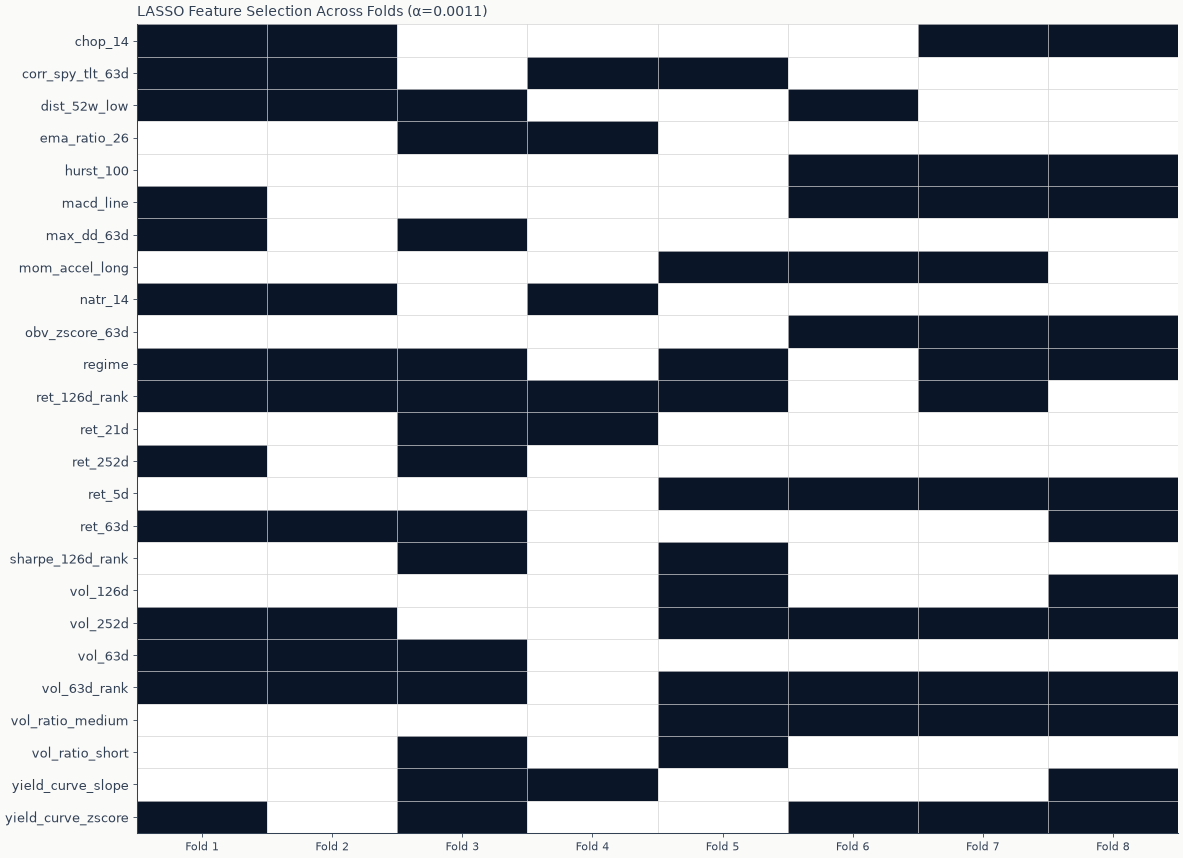

In [19]:
best_lasso_coeffs = lasso_all[best_lasso_alpha]["coeffs"]  # (n_folds, n_features)
nonzero_mask = (np.abs(best_lasso_coeffs) > 1e-8).astype(int)

# Show features that are nonzero in at least 2 folds (reduces clutter for print)
fold_count = nonzero_mask.sum(axis=0)
show_mask = fold_count >= 2
mask_subset = nonzero_mask[:, show_mask]
names_subset = [FEATURE_COLS[i] for i in range(len(FEATURE_COLS)) if show_mask[i]]

cmap_binary = ListedColormap(["white", COLORS["blue"]])  # white / dark navy

fig, ax = plt.subplots(figsize=(12, max(4, len(names_subset) * 0.35)))
ax.imshow(mask_subset.T, aspect="auto", cmap=cmap_binary, interpolation="nearest")
ax.set_xticks(range(mask_subset.shape[0]))
ax.set_xticklabels([f"Fold {i + 1}" for i in range(mask_subset.shape[0])])
ax.set_yticks(range(len(names_subset)))
ax.set_yticklabels(names_subset, fontsize=9)
ax.set_title(f"LASSO Feature Selection Across Folds (α={best_lasso_alpha:.4f})")

# Add grid lines between cells
for i in range(mask_subset.shape[1] + 1):
    ax.axhline(i - 0.5, color="lightgray", lw=0.5)
for j in range(mask_subset.shape[0] + 1):
    ax.axvline(j - 0.5, color="lightgray", lw=0.5)

fig.tight_layout()
fig.show()

Features present in all folds represent robust LASSO selections. Features that
flicker on and off are unstable — their inclusion depends on which training
window the model sees. This motivates Elastic Net, which retains correlated
feature groups rather than picking one arbitrarily.

## Elastic Net (L1 + L2)

Elastic Net blends Ridge and LASSO penalties. We fix alpha at the best LASSO
alpha and vary the L1 ratio: 0.25 (mostly Ridge), 0.50 (balanced), 0.75
(mostly LASSO). This shows how the L1/L2 mix affects sparsity.

In [20]:
if NEED_TRAINING:
    EN_RATIOS = [0.25, 0.50, 0.75]
    en_all = {}

    for ratio in EN_RATIOS:
        key = f"l1={ratio:.2f}"
        res, coeffs, models = cross_validate(
            ElasticNet,
            {
                "alpha": best_lasso_alpha,
                "l1_ratio": ratio,
                "random_state": RANDOM_SEED,
                "max_iter": 5000,
            },
        )
        en_all[key] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "models": models,
            "alpha": best_lasso_alpha,
            "l1_ratio": ratio,
        }

In [21]:
if NEED_TRAINING:
    en_summary = pl.DataFrame(
        [
            {
                "params": k,
                "mean_ic": d["results"]["ic"].mean(),
                "std_ic": d["results"]["ic"].std(),
                "n_nonzero": int((np.abs(d["coeffs"]).mean(axis=0) > 1e-8).sum())
                if d["coeffs"].size > 0
                else 0,
            }
            for k, d in en_all.items()
        ]
    ).sort("mean_ic", descending=True)

    # Filter NaN before selecting best EN key
    _en_valid = en_summary.filter(pl.col("mean_ic").is_not_nan())
    best_en_key = (
        _en_valid.row(0, named=True)["params"]
        if _en_valid.height > 0
        else en_summary.row(0, named=True)["params"]
    )

In [22]:
print("Elastic Net Summary:")
en_summary

Elastic Net Summary:


params,mean_ic,std_ic,n_nonzero
str,f64,f64,i64
"""l1=0.75""",0.043701,0.076839,40
"""l1=0.25""",0.038415,0.067158,48
"""l1=0.50""",0.036929,0.079548,45


We fix $\alpha$ at the best LASSO value to isolate the effect of the L1/L2 mixing
ratio. Higher `l1_ratio` produces more sparsity (closer to LASSO); lower values
retain more features (closer to Ridge). Joint optimization of both $\alpha$ and
`l1_ratio` is demonstrated in `04_nested_cv_hpo`.

## Loss Function Comparison

The section text discusses MSE, MAE, and Huber loss. `SGDRegressor` provides a
unified interface: all three accept L2 penalty and `sample_weight`. We compare
them at the best Ridge alpha to isolate the effect of the loss function.

In [23]:
if NEED_TRAINING:
    # SGDRegressor alpha maps differently: divide by n_samples for comparable regularization
    n_sgd = len(cv_splits[0][0])
    sgd_alpha = best_ridge_alpha / n_sgd

    loss_configs = {
        "MSE (squared)": {"loss": "squared_error", "penalty": "l2", "alpha": sgd_alpha},
        "Huber": {"loss": "huber", "penalty": "l2", "alpha": sgd_alpha},
        "MAE (ε-insensitive)": {"loss": "epsilon_insensitive", "penalty": "l2", "alpha": sgd_alpha},
    }
    loss_results = {}
    for name, params in loss_configs.items():
        res, _, _ = cross_validate(
            SGDRegressor, {**params, "max_iter": 5000, "random_state": RANDOM_SEED}
        )
        loss_results[name] = pl.DataFrame(res)

    loss_comparison = pl.DataFrame(
        [
            {"Loss": name, "Mean IC": df["ic"].mean(), "Std IC": df["ic"].std()}
            for name, df in loss_results.items()
        ]
    ).sort("Mean IC", descending=True)

In [24]:
print("Loss Function Comparison (L2 penalty, same α):")
loss_comparison

Loss Function Comparison (L2 penalty, same α):


Loss,Mean IC,Std IC
str,f64,f64
"""Huber""",0.063384,0.047087
"""MSE (squared)""",0.055531,0.062572
"""MAE (ε-insensitive)""",0.029517,0.050188


Huber loss leads on this fold-set with mean IC around 0.063, edging out squared
error (≈0.056) and ε-insensitive MAE (≈0.030). SGDRegressor is a stochastic
optimizer sensitive to the learning rate schedule, so absolute ICs differ from the
closed-form Ridge solution above — the comparison highlights *relative* behavior.
In the heavy-tailed return distribution, Huber's quadratic-then-linear penalty
downweights extreme residuals without ignoring them, which the squared-error and
ε-insensitive losses do not. The case-study pipelines in Ch12 use LightGBM's
Huber objective for the same reason.

### LASSO Coefficient Path

We use `sklearn.linear_model.lasso_path` on the first fold for an efficient
warm-started coefficient path (much faster than refitting per alpha).

In [25]:
if NEED_TRAINING:
    tr0 = cv_splits[0][0]
    scaler_path = StandardScaler()
    X_path = scaler_path.fit_transform(features_array[tr0])
    y_path = target_array[tr0]
    path_alphas, path_coefs, _ = lasso_path(X_path, y_path, n_alphas=80, random_state=RANDOM_SEED)

### Save Cache

In [26]:
if NEED_TRAINING:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(
        {
            "ols_df": ols_df,
            "ols_coeffs": ols_coeffs,
            "ols_models": ols_models,
            "ridge_all": ridge_all,
            "ridge_summary": ridge_summary,
            "best_ridge_alpha": best_ridge_alpha,
            "RIDGE_ALPHAS": RIDGE_ALPHAS,
            "lasso_all": lasso_all,
            "lasso_summary": lasso_summary,
            "best_lasso_alpha": best_lasso_alpha,
            "alpha_max": alpha_max,
            "LASSO_ALPHAS": LASSO_ALPHAS,
            "en_all": en_all,
            "en_summary": en_summary,
            "best_en_key": best_en_key,
            "path_alphas": path_alphas,
            "path_coefs": path_coefs,
            "sample_weight_results": sample_weight_results,
            "loss_comparison": loss_comparison,
        },
        RESULTS_PATH,
    )
    print(f"Saved results to {RESULTS_PATH}")

## Model Comparison

We compare all four methods using mean IC and its standard deviation across
the 8 walk-forward folds.

In [27]:
rows = [
    {"Model": "OLS", "Mean IC": ols_df["ic"].mean(), "Std IC": ols_df["ic"].std()},
    {
        "Model": f"Ridge (α={best_ridge_alpha:.0f})",
        "Mean IC": ridge_all[best_ridge_alpha]["results"]["ic"].mean(),
        "Std IC": ridge_all[best_ridge_alpha]["results"]["ic"].std(),
    },
    {
        "Model": f"LASSO (α={best_lasso_alpha:.4f})",
        "Mean IC": lasso_all[best_lasso_alpha]["results"]["ic"].mean(),
        "Std IC": lasso_all[best_lasso_alpha]["results"]["ic"].std(),
    },
]

rows.append(
    {
        "Model": f"Elastic Net ({best_en_key})",
        "Mean IC": en_all[best_en_key]["results"]["ic"].mean(),
        "Std IC": en_all[best_en_key]["results"]["ic"].std(),
    }
)

comparison = pl.DataFrame(rows).sort("Mean IC", descending=True)
comparison

Model,Mean IC,Std IC
str,f64,f64
"""Ridge (α=31623)""",0.047338,0.058075
"""LASSO (α=0.0011)""",0.044804,0.077064
"""Elastic Net (l1=0.75)""",0.043701,0.076839
"""OLS""",0.028434,0.052593


### Prediction Rank Stability

How much do the model's cross-sectional rankings change between consecutive
folds? We apply both models (fold $t$ and fold $t+1$) to the same test set
and compute their Spearman rank correlation. High correlation means stable
rankings; low means the model learned fold-specific patterns.

In [28]:
best_ridge_data = ridge_all[best_ridge_alpha]
rank_corrs = []

for i in range(len(cv_splits) - 1):
    _, te_next = cv_splits[i + 1]
    X_te = features_array[te_next]
    m_curr = best_ridge_data["models"][i]
    m_next = best_ridge_data["models"][i + 1]
    pred_curr = m_curr["model"].predict(m_curr["scaler"].transform(X_te))
    pred_next = m_next["model"].predict(m_next["scaler"].transform(X_te))
    rc, _ = spearmanr(pred_curr, pred_next)
    rank_corrs.append(rc)

rank_corr_df = pl.DataFrame(
    {
        "Fold pair": [f"{i + 1}→{i + 2}" for i in range(len(rank_corrs))],
        "Spearman ρ": [round(rc, 4) for rc in rank_corrs],
    }
)
print(f"Mean rank correlation: {np.mean(rank_corrs):.4f}")
rank_corr_df

Mean rank correlation: 0.7596


Fold pair,Spearman ρ
str,f64
"""1→2""",0.9037
"""2→3""",0.9499
"""3→4""",0.644
"""4→5""",0.5147
"""5→6""",0.4677
"""6→7""",0.9434
"""7→8""",0.8935


High rank correlation confirms that Ridge produces stable cross-sectional
rankings across folds — the same features rank near the top across folds
regardless of the training window. Lower values would indicate instability
and high implied turnover.

> **Turnover**: Rank stability is a proxy for signal turnover — the fraction
> of the portfolio that changes between rebalancing dates. The per-case-study
> runner notebooks (`06_linear.py`) compute explicit turnover alongside IC;
> Chapter 17 develops the full turnover-adjusted evaluation framework.
> `ml4t.diagnostic.signal.compute_turnover()` provides the production implementation.

## Regularization Paths

### Ridge IC vs Alpha

Ridge IC is stable across a wide alpha range. Very strong regularization
($\alpha > 1000$) improves IC by biasing coefficients away from OLS's
overfitting — the classic bias-variance tradeoff.

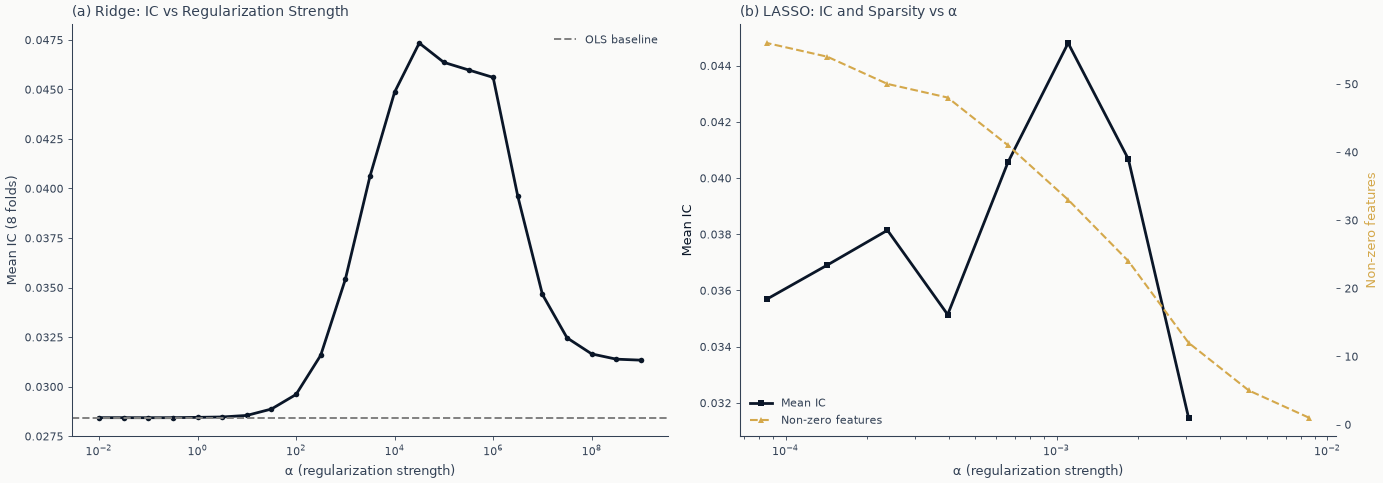

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Ridge IC vs alpha
alphas_sorted = sorted(ridge_all.keys())
ics_ridge = [ridge_all[a]["results"]["ic"].mean() for a in alphas_sorted]

axes[0].semilogx(alphas_sorted, ics_ridge, "o-", color=COLORS["blue"], lw=2)
axes[0].axhline(ols_df["ic"].mean(), ls="--", color="gray", label="OLS baseline")
axes[0].set_xlabel("α (regularization strength)")
axes[0].set_ylabel("Mean IC (8 folds)")
axes[0].set_title("(a) Ridge: IC vs Regularization Strength")
axes[0].legend()

# (b) LASSO IC vs alpha (with nonzero count on secondary axis)
alphas_l = sorted(lasso_all.keys(), reverse=True)
ics_lasso = [lasso_all[a]["results"]["ic"].mean() for a in alphas_l]
nz_lasso = [int((np.abs(lasso_all[a]["coeffs"]).mean(axis=0) > 1e-8).sum()) for a in alphas_l]

ax2 = axes[1]
color_ic = COLORS["blue"]
ax2.semilogx(alphas_l, ics_lasso, "s-", color=color_ic, lw=2, label="Mean IC")
ax2.set_xlabel("α (regularization strength)")
ax2.set_ylabel("Mean IC", color=color_ic)

ax2b = ax2.twinx()
color_nz = COLORS["amber"]
ax2b.semilogx(alphas_l, nz_lasso, "^--", color=color_nz, lw=1.5, label="Non-zero features")
ax2b.set_ylabel("Non-zero features", color=color_nz)
ax2.set_title("(b) LASSO: IC and Sparsity vs α")

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="lower left", frameon=False)

fig.tight_layout()
fig.show()

### LASSO Coefficient Path (Top 10 Features)

The coefficient path from `lasso_path` shows how features enter the model
as $\alpha$ decreases. We highlight only the 10 features with largest
peak magnitude to keep the plot readable.

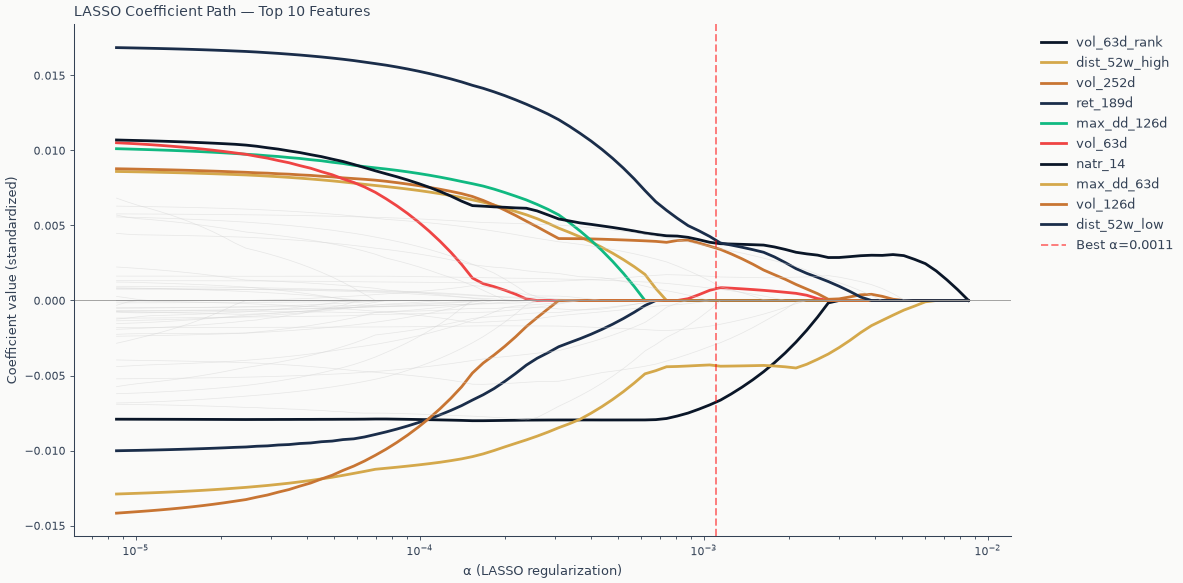

In [30]:
peak_coef = np.max(np.abs(path_coefs), axis=1)
top10_idx = np.argsort(peak_coef)[-10:]
top10_names = [FEATURE_COLS[i] for i in top10_idx]

fig, ax = plt.subplots(figsize=(12, 6))

for i in top10_idx:
    ax.semilogx(path_alphas, path_coefs[i], lw=2, label=FEATURE_COLS[i])

for i in range(path_coefs.shape[0]):
    if i not in top10_idx:
        ax.semilogx(path_alphas, path_coefs[i], lw=0.5, color="lightgray", alpha=0.5)

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(
    best_lasso_alpha, ls="--", color="red", alpha=0.5, label=f"Best α={best_lasso_alpha:.4f}"
)
ax.set_xlabel("α (LASSO regularization)")
ax.set_ylabel("Coefficient value (standardized)")
ax.set_title("LASSO Coefficient Path — Top 10 Features")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig.tight_layout()
fig.show()

### Ridge IC and ICIR vs Alpha

The extended alpha grid reveals the full regularization landscape: a flat zone
where Ridge matches OLS, an improving zone where shrinkage helps, and an
over-regularized zone where coefficients are crushed too aggressively.

In [31]:
alphas_sorted_full = sorted(ridge_all.keys())
ics_full = np.array([ridge_all[a]["results"]["ic"].mean() for a in alphas_sorted_full])
stds_full = np.array([ridge_all[a]["results"]["ic"].std() for a in alphas_sorted_full])
icirs_full = ics_full / np.where(stds_full > 0, stds_full, np.nan)

ols_ic = ols_df["ic"].mean()
ols_std = ols_df["ic"].std()
ols_icir = ols_ic / ols_std if ols_std > 0 else 0

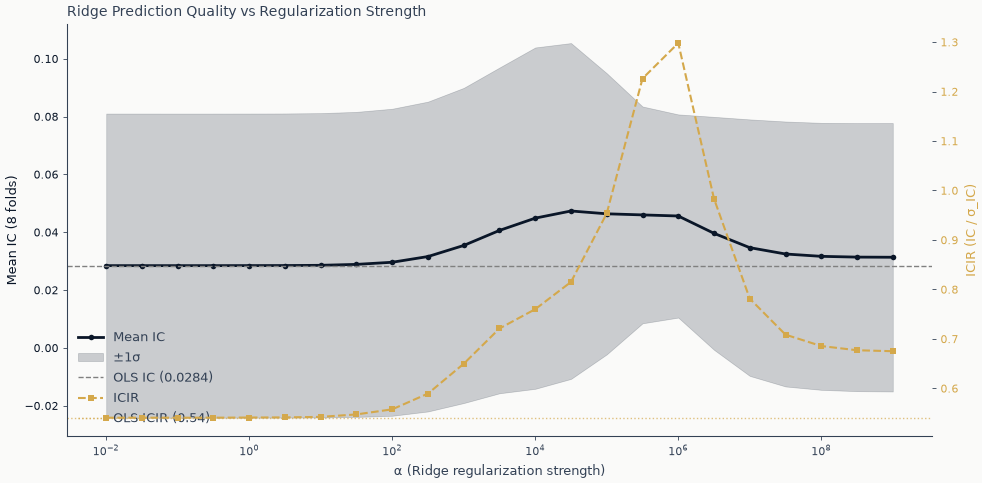

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# IC with ±1σ band
ax1.semilogx(alphas_sorted_full, ics_full, "o-", color=COLORS["blue"], lw=2, ms=4, label="Mean IC")
ax1.fill_between(
    alphas_sorted_full,
    ics_full - stds_full,
    ics_full + stds_full,
    alpha=0.2,
    color=COLORS["blue"],
    label="±1σ",
)
ax1.axhline(ols_ic, ls="--", color="gray", lw=1, label=f"OLS IC ({ols_ic:.4f})")
ax1.set_xlabel("α (Ridge regularization strength)")
ax1.set_ylabel("Mean IC (8 folds)", color=COLORS["blue"])
ax1.tick_params(axis="y", labelcolor=COLORS["blue"])

# ICIR on secondary axis
ax2 = ax1.twinx()
ax2.semilogx(
    alphas_sorted_full, icirs_full, "s--", color=COLORS["amber"], lw=1.5, ms=4, label="ICIR"
)
ax2.axhline(
    ols_icir, ls=":", color=COLORS["amber"], lw=1, alpha=0.7, label=f"OLS ICIR ({ols_icir:.2f})"
)
ax2.set_ylabel("ICIR (IC / σ_IC)", color=COLORS["amber"])
ax2.tick_params(axis="y", labelcolor=COLORS["amber"])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=9)

ax1.set_title("Ridge Prediction Quality vs Regularization Strength")
fig.tight_layout()
fig.show()

### Ridge IC/ICIR Statistics

Key statistics from the regularization sweep.

In [33]:
best_idx = np.argmax(icirs_full)
best_alpha = alphas_sorted_full[best_idx]
best_icir = icirs_full[best_idx]
best_ic = ics_full[best_idx]
best_std = stds_full[best_idx]
n_samples = sum(len(tr) + len(te) for tr, te in cv_splits)

print("=== Ridge IC/ICIR Statistics ===")
print(
    f"Alpha range: {alphas_sorted_full[0]:.0e} to {alphas_sorted_full[-1]:.0e} ({len(alphas_sorted_full)} values)"
)
print(f"Total sample size: {df.height:,}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"OLS baseline: IC={ols_ic:.4f}, std={ols_std:.4f}, ICIR={ols_icir:.2f}")
print(f"Best ICIR: {best_icir:.2f} at α={best_alpha:.0e}")
print(f"  Mean IC: {best_ic:.4f}, Std IC: {best_std:.4f}")
print(f"  IC improvement: {(best_ic - ols_ic) / abs(ols_ic) * 100:.0f}%")
print(f"  Std reduction: {(1 - best_std / ols_std) * 100:.0f}%")
print(f"  ICIR improvement: {best_icir / ols_icir:.1f}x over OLS ({ols_icir:.2f})")

=== Ridge IC/ICIR Statistics ===
Alpha range: 1e-02 to 1e+09 (23 values)
Total sample size: 393,985
Features: 57
OLS baseline: IC=0.0284, std=0.0526, ICIR=0.54
Best ICIR: 1.30 at α=1e+06
  Mean IC: 0.0456, Std IC: 0.0351
  IC improvement: 60%
  Std reduction: 33%
  ICIR improvement: 2.4x over OLS (0.54)


### Combined Regularization Path

The three panels below summarize the sweep: the Ridge coefficient path, the
LASSO sparsity path, and the cross-model IC comparison side by side.

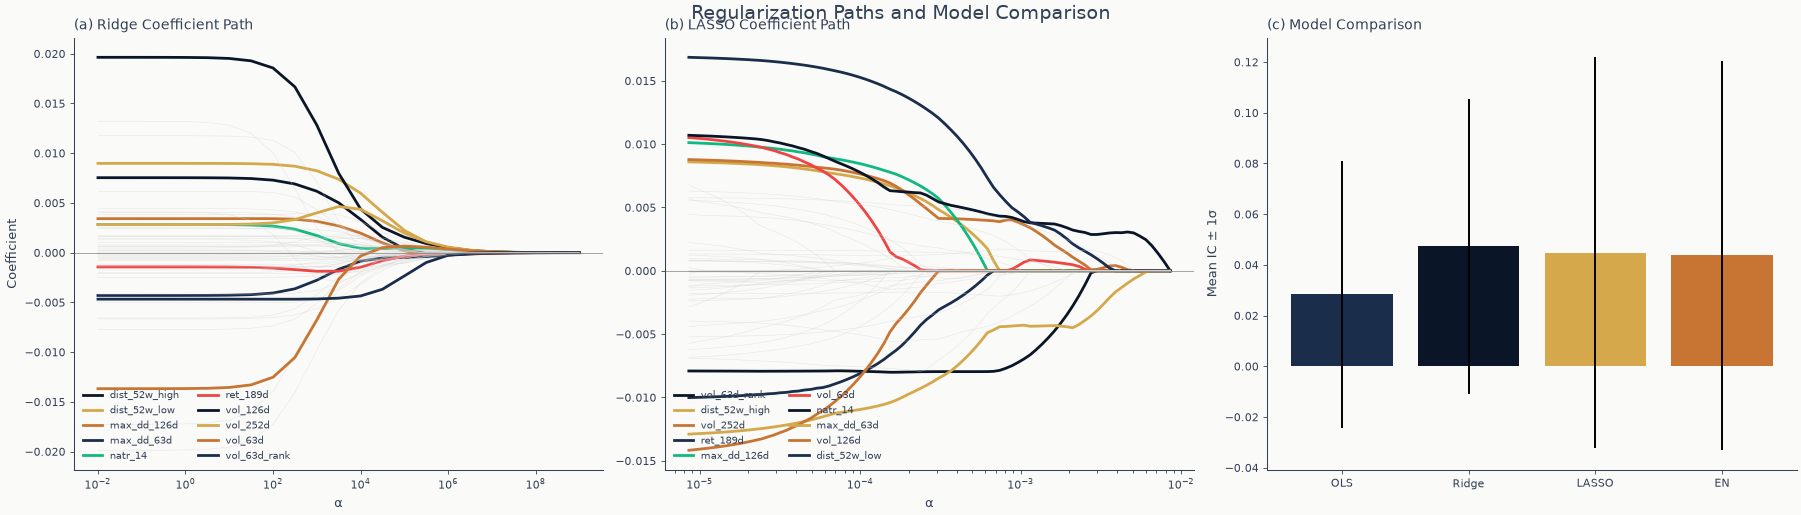

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Ridge coefficient path
for j, feat in enumerate(FEATURE_COLS):
    coefs_by_alpha = [ridge_all[a]["coeffs"].mean(axis=0)[j] for a in alphas_sorted]
    if feat in top10_names:
        axes[0].semilogx(alphas_sorted, coefs_by_alpha, lw=2, label=feat)
    else:
        axes[0].semilogx(alphas_sorted, coefs_by_alpha, lw=0.4, color="lightgray", alpha=0.5)
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].set_xlabel("α")
axes[0].set_ylabel("Coefficient")
axes[0].set_title("(a) Ridge Coefficient Path")
axes[0].legend(fontsize=7, loc="lower left", ncol=2, frameon=False)

# (b) LASSO coefficient path
for i in top10_idx:
    axes[1].semilogx(path_alphas, path_coefs[i], lw=2, label=FEATURE_COLS[i])
for i in range(path_coefs.shape[0]):
    if i not in top10_idx:
        axes[1].semilogx(path_alphas, path_coefs[i], lw=0.4, color="lightgray", alpha=0.5)
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set_xlabel("α")
axes[1].set_title("(b) LASSO Coefficient Path")
axes[1].legend(fontsize=7, loc="lower left", ncol=2, frameon=False)

# (c) IC comparison across methods
x_pos = np.arange(4)
ics = [
    ols_df["ic"].mean(),
    ridge_all[best_ridge_alpha]["results"]["ic"].mean(),
    lasso_all[best_lasso_alpha]["results"]["ic"].mean(),
    en_all[best_en_key]["results"]["ic"].mean(),
]
stds = [
    ols_df["ic"].std(),
    ridge_all[best_ridge_alpha]["results"]["ic"].std(),
    lasso_all[best_lasso_alpha]["results"]["ic"].std(),
    en_all[best_en_key]["results"]["ic"].std(),
]
labels = ["OLS", "Ridge", "LASSO", "EN"]
axes[2].bar(
    x_pos,
    ics,
    yerr=stds,
    capsize=4,
    color=[COLORS["slate"], COLORS["blue"], COLORS["amber"], COLORS["copper"]],
)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel("Mean IC ± 1σ")
axes[2].set_title("(c) Model Comparison")

fig.suptitle("Regularization Paths and Model Comparison", fontsize=14, y=1.02)
plt.show()
plt.close()

Panels (a) and (b) contrast Ridge's smooth shrinkage with LASSO's sequential
elimination. Ridge retains all features with attenuated weights; LASSO selects a
sparse subset whose composition can shift across folds. Panel (c) shows that
regularization consistently improves over OLS, with LASSO and Ridge achieving
the highest mean IC.

## Key Takeaways

1. **Ridge improves IC** over OLS by shrinking noisy coefficients — the
   bias-variance tradeoff favors more bias when features outnumber signal.

2. **LASSO performs feature selection**: at the best alpha, a little over half
   of the features survive (33 of 57). The coefficient path reveals which
   features enter the model first as regularization weakens.

3. **Elastic Net** blends both penalties. Higher L1 ratio produces more
   sparsity; the choice depends on whether you value interpretability or
   want to retain correlated features.

4. **Walk-forward CV with purging** is essential — standard K-fold would
   overestimate IC by allowing information leakage across the purge gap.

**Next**: See `03_logistic_classification` for direction prediction, or
`04_nested_cv_hpo` for hyperparameter optimization with Optuna.